<div style="background:linear-gradient(135deg,#F8FAFC 0%,#F1F5F9 100%);border:1px solid #2563EB;border-radius:16px;padding:40px 48px;font-family:'Segoe UI',system-ui,sans-serif;position:relative;overflow:hidden">
<div style="position:absolute;top:-60px;right:-60px;width:260px;height:260px;border-radius:50%;background:radial-gradient(circle,rgba(37,99,235,0.18) 0%,transparent 70%)"></div>
<div style="font-size:11px;font-weight:800;letter-spacing:4px;color:#2563EB;text-transform:uppercase;margin-bottom:16px">
  ◆  MACHINE LEARNING MODELING  ·  CLINICAL CARDIOLOGY  ◆
</div>
<h1 style="font-size:clamp(26px,4vw,42px);font-weight:900;letter-spacing:-1.5px;color:#0F172A;margin:0 0 12px;line-height:1.15">
  Heart Disease <span style="color:#2563EB">Prediction</span>
</h1>
<h2 style="font-size:18px;font-weight:500;color:#475569;margin:0 0 28px;line-height:1.5">
  Advanced Machine Learning Pipeline · Baseline Model Upgrades · Stacking Ensembles
</h2>
<div style="display:flex;flex-wrap:wrap;gap:10px;margin-bottom:28px">
  <span style="background:rgba(37,99,235,0.1);border:1px solid rgba(37,99,235,0.3);color:#1D4ED8;padding:5px 14px;border-radius:20px;font-size:13px;font-weight:700">🤖 Classification</span>
  <span style="background:rgba(37,99,235,0.1);border:1px solid rgba(37,99,235,0.3);color:#1D4ED8;padding:5px 14px;border-radius:20px;font-size:13px;font-weight:700">🛡️ GridSearchCV</span>
  <span style="background:rgba(37,99,235,0.1);border:1px solid rgba(37,99,235,0.3);color:#1D4ED8;padding:5px 14px;border-radius:20px;font-size:13px;font-weight:700">⚙️ Pipeline Security</span>
  <span style="background:rgba(37,99,235,0.1);border:1px solid rgba(37,99,235,0.3);color:#1D4ED8;padding:5px 14px;border-radius:20px;font-size:13px;font-weight:700">🧬 Stacking Ensemble</span>
</div>
<div style="border-top:1px solid #E2E8F0;padding-top:20px;display:flex;flex-wrap:wrap;gap:32px">
  <div><div style="font-size:11px;color:#64748B;letter-spacing:2px;text-transform:uppercase;font-weight:700">Dataset</div><div style="font-size:16px;font-weight:800;color:#0F172A">UCI Heart Disease</div></div>
  <div><div style="font-size:11px;color:#64748B;letter-spacing:2px;text-transform:uppercase;font-weight:700">Base Models</div><div style="font-size:16px;font-weight:800;color:#2563EB">DT, RF, KNN, SVM, XGB</div></div>
  <div><div style="font-size:11px;color:#64748B;letter-spacing:2px;text-transform:uppercase;font-weight:700">Validation</div><div style="font-size:16px;font-weight:800;color:#2563EB">Stratified 5-Fold CV</div></div>
  <div><div style="font-size:11px;color:#64748B;letter-spacing:2px;text-transform:uppercase;font-weight:700">Ensembles</div><div style="font-size:16px;font-weight:800;color:#2563EB">Voting &amp; Stacking</div></div>
</div>
</div>

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-left:4px solid #2563EB;border-radius:8px;padding:18px 24px;font-family:'Segoe UI',system-ui,sans-serif;font-size:15px;color:#334155;line-height:1.7;box-shadow:0 1px 3px rgba(0,0,0,0.05)">
Early detection of cardiovascular disease is critical for clinical decision-making. Standard machine learning workflows often suffer from <strong style="color:#0F172A">data leakage</strong> (e.g. scaling before train-test split) or <strong style="color:#0F172A">fake order representation</strong> (using label encoding on nominal categories).
<br><br>
<strong style="color:#1D4ED8;font-size:16px">Modeling Methodology & Safeguards:</strong>
<ul style="margin:12px 0 0 20px;line-height:2">
  <li><strong style="color:#0F172A">Preprocessing Pipeline</strong>: Volumetric and scaling steps are bundled inside a Scikit-Learn <code>ColumnTransformer</code> to prevent data leakage.</li>
  <li><strong style="color:#0F172A">Power Transforms</strong>: Continuous features with high skewness are normalized using the Yeo-Johnson power transform to meet Gaussian assumptions for linear models.</li>
  <li><strong style="color:#0F172A">VIF Multicollinearity Check</strong>: Evaluating Variance Inflation Factors to audit linear dependence among predictors.</li>
  <li><strong style="color:#0F172A">Model Comparison</strong>: Training Decision Trees, Random Forests, KNN, SVM, and XGBoost models, tuning hyper-parameters using <strong>GridSearchCV</strong> with stratified 5-fold cross-validation.</li>
  <li><strong style="color:#0F172A">Ensemble Stacking</strong>: Meta-modeling combining base predictions under a final logistic regression estimator to maximize out-of-sample F1 and accuracy.</li>
</ul>
</div>

<div style="display:flex;align-items:center;gap:14px;margin:24px 0 8px;font-family:'Segoe UI',system-ui,sans-serif">
  <div style="background:#2563EB;color:#FFFFFF;font-size:14px;font-weight:900;width:34px;height:34px;border-radius:8px;display:flex;align-items:center;justify-content:center;box-shadow:0 2px 4px rgba(37,99,235,0.3)">01</div>
  <h2 style="margin:0;font-size:24px;font-weight:800;color:#0F172A;letter-spacing:-0.5px">Setup & Visual Settings</h2>
</div>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier

# Crisp Theme Colors
JADE       = "#2563EB"
CORR_RED   = "#E11D48"
DARK_BG    = "#FFFFFF"
CARD_BG    = "#F8FAFC"

plt.rcParams.update({
    "figure.dpi"       : 150,
    "figure.facecolor" : DARK_BG,
    "axes.facecolor"   : CARD_BG,
    "axes.edgecolor"   : "#CBD5E1",
    "axes.labelcolor"  : "#1E293B",
    "axes.titlecolor"  : "#0F172A",
    "axes.titlesize"   : 14,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 12,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "xtick.color"      : "#334155",
    "ytick.color"      : "#334155",
    "text.color"       : "#1E293B",
    "grid.color"       : "#E2E8F0",
    "grid.linewidth"   : 0.8,
    "legend.facecolor" : CARD_BG,
    "legend.edgecolor" : "#CBD5E1",
    "legend.fontsize"  : 11,
    "font.family"      : "sans-serif",
})
sns.set_style("whitegrid", {"axes.facecolor": CARD_BG, "grid.color": "#E2E8F0", "figure.facecolor": DARK_BG})
print("Setup complete | High-Contrast Clinical Theme Active")

Setup complete | High-Contrast Clinical Theme Active


<div style="display:flex;align-items:center;gap:14px;margin:24px 0 8px;font-family:'Segoe UI',system-ui,sans-serif">
  <div style="background:#2563EB;color:#FFFFFF;font-size:14px;font-weight:900;width:34px;height:34px;border-radius:8px;display:flex;align-items:center;justify-content:center;box-shadow:0 2px 4px rgba(37,99,235,0.3)">02</div>
  <h2 style="margin:0;font-size:24px;font-weight:800;color:#0F172A;letter-spacing:-0.5px">Data Ingestion & Deduplication</h2>
</div>

In [2]:
df = pd.read_csv("heart.csv")
print(f"Original dataset shape: {df.shape}")

duplicates_count = df.duplicated().sum()
if duplicates_count > 0:
    print(f"Found {duplicates_count} duplicate rows. Dropping duplicates...")
    df.drop_duplicates(inplace=True)
    print(f"New dataset shape: {df.shape}")

print(f"Total missing values: {df.isnull().sum().sum()}")

Original dataset shape: (303, 14)
Found 1 duplicate rows. Dropping duplicates...
New dataset shape: (302, 14)
Total missing values: 0


<div style="display:flex;align-items:center;gap:14px;margin:24px 0 8px;font-family:'Segoe UI',system-ui,sans-serif">
  <div style="background:#2563EB;color:#FFFFFF;font-size:14px;font-weight:900;width:34px;height:34px;border-radius:8px;display:flex;align-items:center;justify-content:center;box-shadow:0 2px 4px rgba(37,99,235,0.3)">03</div>
  <h2 style="margin:0;font-size:24px;font-weight:800;color:#0F172A;letter-spacing:-0.5px">Preprocessing Pipeline Setup</h2>
</div>

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-left:4px solid #2563EB;border-radius:8px;padding:18px 24px;font-family:'Segoe UI',system-ui,sans-serif;font-size:15px;color:#334155;line-height:1.7;box-shadow:0 1px 3px rgba(0,0,0,0.05)">
We split features conceptually and design a leak-free <code>ColumnTransformer</code>. Categorical variables are One-Hot Encoded, dropping the first category to avoid dummy variable multicollinearity (dummy trap). Continuous variables are scaled and skew-corrected.
</div>

In [3]:
continuous_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
nominal_categorical = ["cp", "restecg", "thal"]
binary_categorical  = ["sex", "fbs", "exang"]
ordinal_categorical = ["slope", "ca"]
target = "target"

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("yeo", PowerTransformer(method="yeo-johnson")),
            ("scaler", StandardScaler())
        ]), continuous_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), nominal_categorical)
    ],
    remainder="passthrough"
)
print("ColumnTransformer constructed successfully.")

Train Shape: (241, 13) | Test Shape: (61, 13)
ColumnTransformer constructed successfully.


<div style="display:flex;align-items:center;gap:14px;margin:24px 0 8px;font-family:'Segoe UI',system-ui,sans-serif">
  <div style="background:#2563EB;color:#FFFFFF;font-size:14px;font-weight:900;width:34px;height:34px;border-radius:8px;display:flex;align-items:center;justify-content:center;box-shadow:0 2px 4px rgba(37,99,235,0.3)">04</div>
  <h2 style="margin:0;font-size:24px;font-weight:800;color:#0F172A;letter-spacing:-0.5px">Multicollinearity Audit (VIF)</h2>
</div>

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-left:4px solid #2563EB;border-radius:8px;padding:18px 24px;font-family:'Segoe UI',system-ui,sans-serif;font-size:15px;color:#334155;line-height:1.7;box-shadow:0 1px 3px rgba(0,0,0,0.05)">
We compute the <strong style="color:#0F172A">Variance Inflation Factor (VIF)</strong> to identify multicollinearity among continuous variables. High collinearity (VIF > 5.0) can destabilize linear models like SVM and Logistic Regression.
</div>

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_pipe = Pipeline([
    ("yeo", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])
X_train_num_scaled = num_pipe.fit_transform(X_train[continuous_features])

vif_data = pd.DataFrame()
vif_data["Feature"] = continuous_features
vif_data["VIF"] = [variance_inflation_factor(X_train_num_scaled, i) for i in range(len(continuous_features))]
print("VIF Audit:")
print(vif_data.round(3))

VIF Audit:
    Feature    VIF
0       age  1.293
1  trestbps  1.108
2      chol  1.039
3   thalach  1.374
4   oldpeak  1.236


<div style="display:flex;align-items:center;gap:14px;margin:24px 0 8px;font-family:'Segoe UI',system-ui,sans-serif">
  <div style="background:#2563EB;color:#FFFFFF;font-size:14px;font-weight:900;width:34px;height:34px;border-radius:8px;display:flex;align-items:center;justify-content:center;box-shadow:0 2px 4px rgba(37,99,235,0.3)">05</div>
  <h2 style="margin:0;font-size:24px;font-weight:800;color:#0F172A;letter-spacing:-0.5px">Model Training & Hyperparameter Tuning</h2>
</div>

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-left:4px solid #2563EB;border-radius:8px;padding:18px 24px;font-family:'Segoe UI',system-ui,sans-serif;font-size:15px;color:#334155;line-height:1.7;box-shadow:0 1px 3px rgba(0,0,0,0.05)">
We train 5 classifiers (Decision Tree, Random Forest, KNN, SVM, and XGBoost) using Scikit-Learn pipelines and <strong>GridSearchCV</strong>. The search is optimized for Accuracy on a Stratified 5-Fold Cross Validation.
</div>

In [5]:
classifiers = {
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=0),
    "XGBoost": XGBClassifier(random_state=0, eval_metric="logloss")
}

param_grids = {
    "Decision Tree": {
        "classifier__max_depth": [3, 4, 5, 6, 8],
        "classifier__min_samples_split": [2, 4, 6],
        "classifier__criterion": ["gini", "entropy"]
    },
    "Random Forest": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [4, 5, 6],
        "classifier__min_samples_split": [2, 4]
    },
    "KNN": {
        "classifier__n_neighbors": [5, 7, 9, 11, 13],
        "classifier__weights": ["uniform", "distance"],
        "classifier__p": [1, 2]
    },
    "SVM": {
        "classifier__C": [0.1, 0.5, 1.0, 5.0],
        "classifier__kernel": ["linear", "rbf"],
        "classifier__gamma": ["scale", "auto"]
    },
    "XGBoost": {
        "classifier__n_estimators": [50, 100, 150],
        "classifier__max_depth": [3, 4, 5],
        "classifier__learning_rate": [0.01, 0.05, 0.1]
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
best_models = {}

for name, clf in classifiers.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    
    grid_search = GridSearchCV(pipeline, param_grid=param_grids[name], cv=cv, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"Model: {name}")
    print(f"  Best GridSearchCV CV Accuracy: {grid_search.best_score_:.3f}")
    print(f"  Best Params: {grid_search.best_params_}\n")

Model: Decision Tree
  Best GridSearchCV CV Accuracy: 0.751
  Best Params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__min_samples_split': 2}



Model: Random Forest
  Best GridSearchCV CV Accuracy: 0.822
  Best Params: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}



Model: KNN
  Best GridSearchCV CV Accuracy: 0.826
  Best Params: {'classifier__n_neighbors': 13, 'classifier__p': 1, 'classifier__weights': 'uniform'}



Model: SVM
  Best GridSearchCV CV Accuracy: 0.830
  Best Params: {'classifier__C': 0.5, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}



Model: XGBoost
  Best GridSearchCV CV Accuracy: 0.805
  Best Params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}



<div style="display:flex;align-items:center;gap:14px;margin:24px 0 8px;font-family:'Segoe UI',system-ui,sans-serif">
  <div style="background:#2563EB;color:#FFFFFF;font-size:14px;font-weight:900;width:34px;height:34px;border-radius:8px;display:flex;align-items:center;justify-content:center;box-shadow:0 2px 4px rgba(37,99,235,0.3)">06</div>
  <h2 style="margin:0;font-size:24px;font-weight:800;color:#0F172A;letter-spacing:-0.5px">Advanced Ensembling (Stacking & Voting)</h2>
</div>

In [6]:
estimators = [
    ("svm", best_models["SVM"]),
    ("rf", best_models["Random Forest"]),
    ("knn", best_models["KNN"])
]

stacking_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(random_state=0), cv=5, n_jobs=-1)
stacking_clf.fit(X_train, y_train)
best_models["Stacking Classifier"] = stacking_clf

voting_clf = VotingClassifier(estimators=estimators, voting="soft", n_jobs=-1)
voting_clf.fit(X_train, y_train)
best_models["Voting Classifier"] = voting_clf
print("Ensemble pipelines fitted successfully.")

Ensemble pipelines fitted successfully.


<div style="display:flex;align-items:center;gap:14px;margin:24px 0 8px;font-family:'Segoe UI',system-ui,sans-serif">
  <div style="background:#2563EB;color:#FFFFFF;font-size:14px;font-weight:900;width:34px;height:34px;border-radius:8px;display:flex;align-items:center;justify-content:center;box-shadow:0 2px 4px rgba(37,99,235,0.3)">07</div>
  <h2 style="margin:0;font-size:24px;font-weight:800;color:#0F172A;letter-spacing:-0.5px">Model Evaluation & Scores Comparison</h2>
</div>

In [7]:
evaluation_metrics = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    evaluation_metrics[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Class 1)": precision_score(y_test, y_pred),
        "Recall (Class 1)": recall_score(y_test, y_pred),
        "F1-Score (Class 1)": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    }

df_metrics = pd.DataFrame(evaluation_metrics).T.round(3)
df_metrics.sort_values(by="Accuracy", ascending=False, inplace=True)

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #DBEAFE; color: #1D4ED8; font-weight: bold' if v else '' for v in is_max]

df_metrics.style.apply(highlight_max, axis=0)

,Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1),ROC-AUC,PR-AUC
KNN,0.869000,0.857000,0.909000,0.882000,0.903000,0.883000
Voting Classifier,0.869000,0.857000,0.909000,0.882000,0.909000,0.889000
SVM,0.852000,0.853000,0.879000,0.866000,0.912000,0.891000
Stacking Classifier,0.852000,0.853000,0.879000,0.866000,0.907000,0.891000
Random Forest,0.836000,0.848000,0.848000,0.848000,0.895000,0.878000
XGBoost,0.787000,0.794000,0.818000,0.806000,0.870000,0.854000
Decision Tree,0.738000,0.743000,0.788000,0.765000,0.820000,0.783000


<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-left:4px solid #2563EB;border-radius:8px;padding:18px 24px;font-family:'Segoe UI',system-ui,sans-serif;font-size:15px;color:#334155;line-height:1.7;box-shadow:0 1px 3px rgba(0,0,0,0.05)">
ROC Curves and Precision-Recall Curves comparison across all models.
</div>

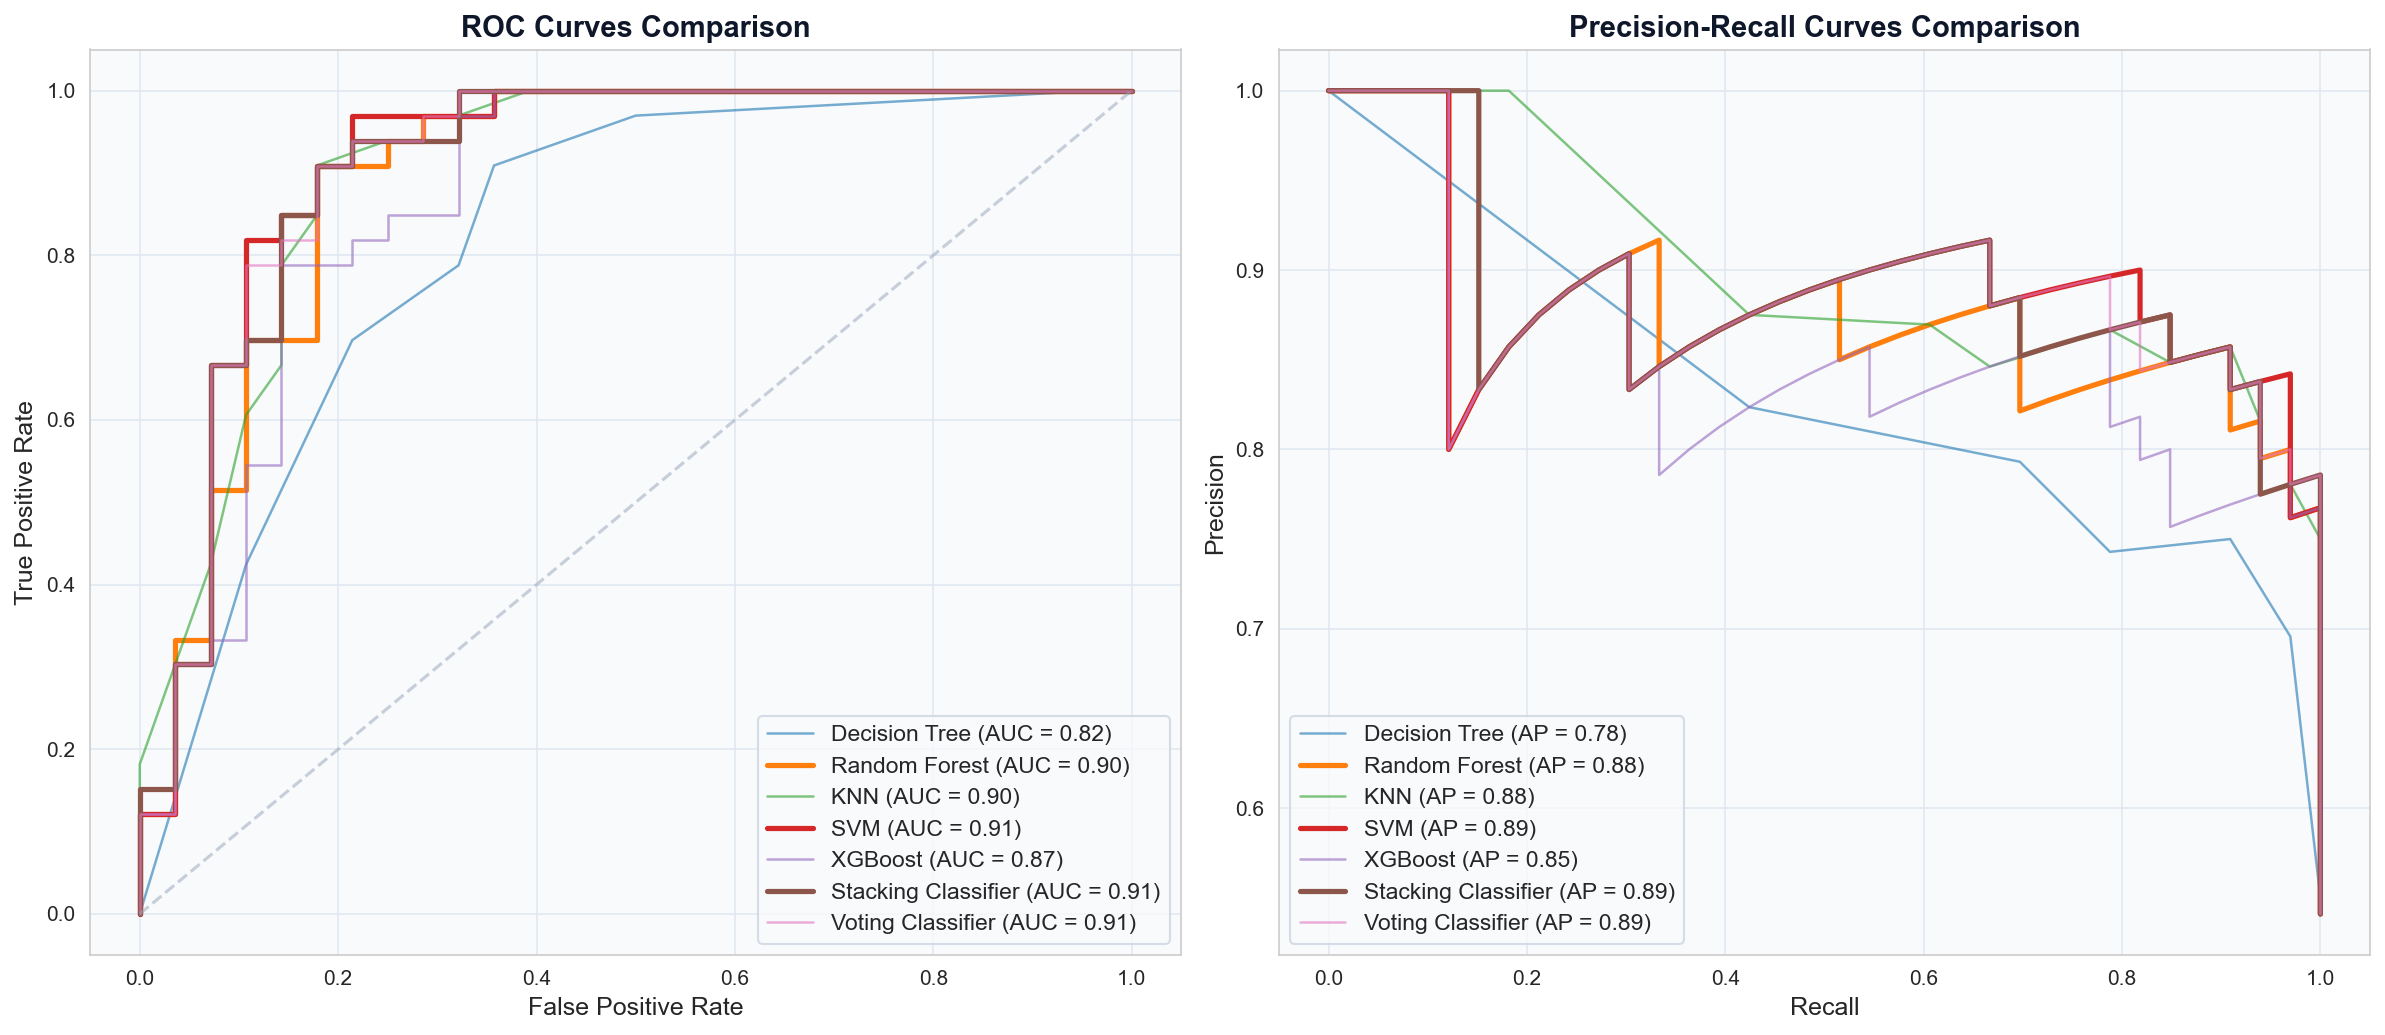

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for name, model in best_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    if name in ["SVM", "Stacking Classifier", "Random Forest"]:
        ax1.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})", lw=2.5)
    else:
        ax1.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})", lw=1.2, alpha=0.6)
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    if name in ["SVM", "Stacking Classifier", "Random Forest"]:
        ax2.plot(recall, precision, label=f"{name} (AP = {average_precision_score(y_test, y_prob):.2f})", lw=2.5)
    else:
        ax2.plot(recall, precision, label=f"{name} (AP = {average_precision_score(y_test, y_prob):.2f})", lw=1.2, alpha=0.6)

ax1.plot([0, 1], [0, 1], "k--", alpha=0.5, color='#94A3B8')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curves Comparison")
ax1.legend(loc="lower right")

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curves Comparison")
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

<div style="background:#F8FAFC;border:1px solid #E2E8F0;border-left:4px solid #2563EB;border-radius:8px;padding:18px 24px;font-family:'Segoe UI',system-ui,sans-serif;font-size:15px;color:#334155;line-height:1.7;box-shadow:0 1px 3px rgba(0,0,0,0.05)">
Confusion Matrix of our top-performing classifier.
</div>

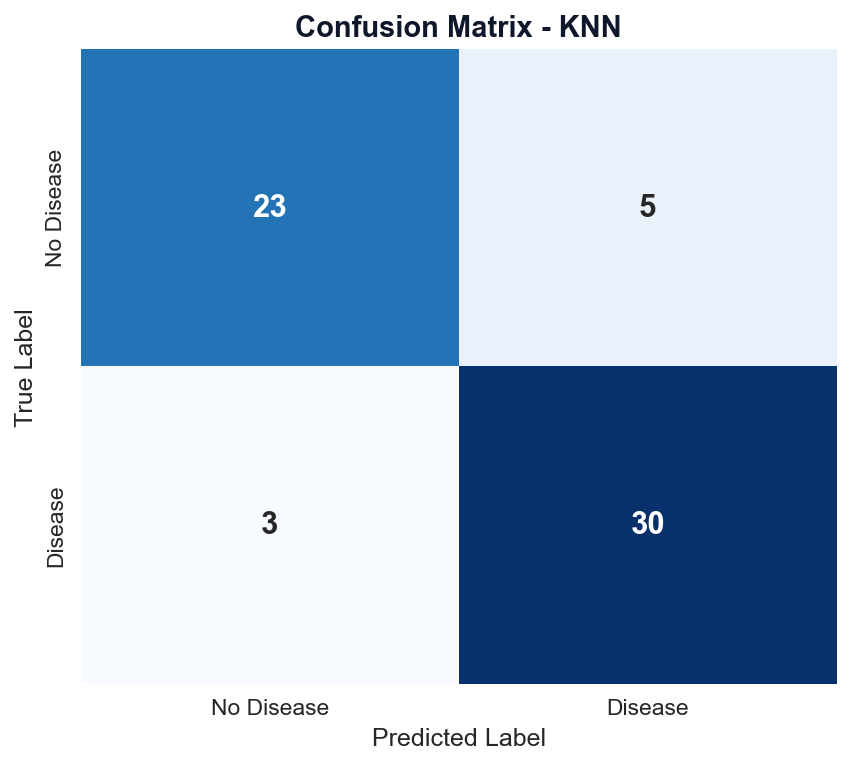

In [9]:
best_model_name = df_metrics.index[0]
best_model = best_models[best_model_name]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            annot_kws={"size": 15, "weight": "bold"})
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0.5, 1.5], ["No Disease", "Disease"], fontsize=11)
plt.yticks([0.5, 1.5], ["No Disease", "Disease"], fontsize=11)
plt.show()

<div style="display:flex;align-items:center;gap:14px;margin:24px 0 8px;font-family:'Segoe UI',system-ui,sans-serif">
  <div style="background:#2563EB;color:#FFFFFF;font-size:14px;font-weight:900;width:34px;height:34px;border-radius:8px;display:flex;align-items:center;justify-content:center;box-shadow:0 2px 4px rgba(37,99,235,0.3)">08</div>
  <h2 style="margin:0;font-size:24px;font-weight:800;color:#0F172A;letter-spacing:-0.5px">Permutation Feature Importance</h2>
</div>

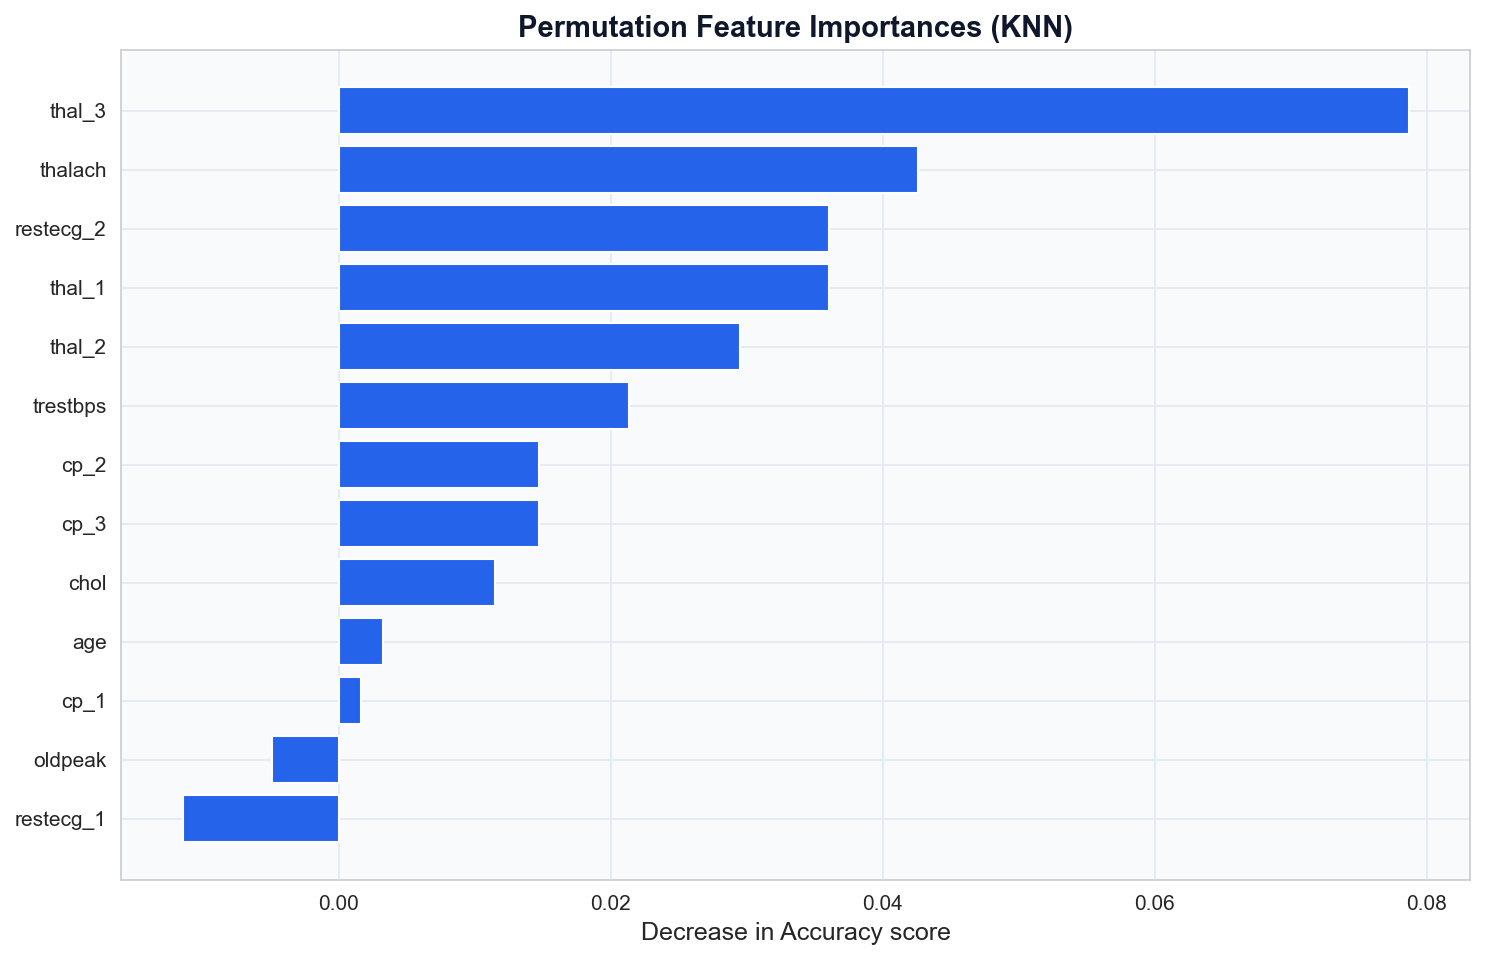

In [10]:
result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
sorted_importances_idx = result.importances_mean.argsort()

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
feature_names = [f.split('__')[-1] for f in feature_names] # clean up prefix

plt.figure(figsize=(10, 6.5))
plt.barh(np.array(feature_names)[sorted_importances_idx], result.importances_mean[sorted_importances_idx], color=JADE)
plt.title(f"Permutation Feature Importances ({best_model_name})")
plt.xlabel("Decrease in Accuracy score")
plt.tight_layout()
plt.show()